# 温泉のマーケット分析

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import japanize_matplotlib

In [63]:
months = np.arange(1, 25)          # 5年分（1〜60ヶ月）
price_per_package = 20000          # パッケージ価格
commission_rate = 0.20             # 手数料率（20%）
initial_sales_per_month = 100      # 初月の販売件数
growth_rate = 0.07        # 月間成長率（7%と仮定。0.05〜0.10が一般的）

In [64]:
unit_revenue = price_per_package * commission_rate
sales = initial_sales_per_month * (1+growth_rate)**(months-1)
monthly_revenue = sales * unit_revenue

In [89]:

growth_pro = 0.03
sale_pro_initial = 2000 * 0.28 * 50
sales_product = sale_pro_initial * (1+growth_pro)**(months-1)

In [90]:
content_sales_initial = 20000
content_growth = 0.15
sales_content = content_sales_initial * (1+content_growth)**(months-1)

In [91]:
Initial_cost = 1000000
cost_growth = 0.01
cost = Initial_cost * (cost_growth + 1)**(months-1)

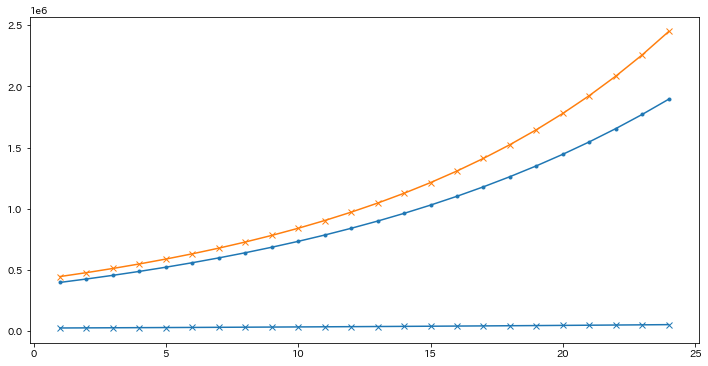

In [92]:
df = pd.DataFrame({
    'Month' : months,
    'Sales_count': sales.astype(int),
    'Revenue': monthly_revenue.astype(int),
    'Product' : sales_product.astype(int),
    'Content': sales_content.astype(int),
    'Total_rev': monthly_revenue + sales_product + sales_content,
    'Cost': -(cost.astype(int))

})

plt.figure(figsize=(12, 6))
plt.plot(df['Month'], df['Revenue'], marker='o', color='#1f77b4', markersize=3, label='Monthly Revenue')
plt.plot(df['Month'],df['Product'],marker='x')
plt.plot(df['Month'],df['Total_rev'],marker='x')

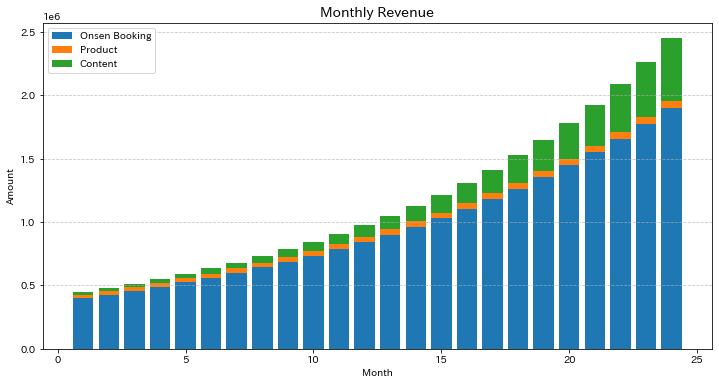

In [93]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))


plt.bar(df['Month'], df['Revenue'], label='Onsen Booking', color='#1f77b4')
plt.bar(df['Month'], df['Product'], bottom=df['Revenue'], label='Product', color='#ff7f0e')
plt.bar(df['Month'], df['Content'], bottom=df['Revenue'] + df['Product'], label='Content', color='#2ca02c')
#plt.bar(df['Month'], df['Cost'], bottom=df['Revenue'] + df['Product'] + df['Content'], label='Cost', color='red')


plt.title('Monthly Revenue', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

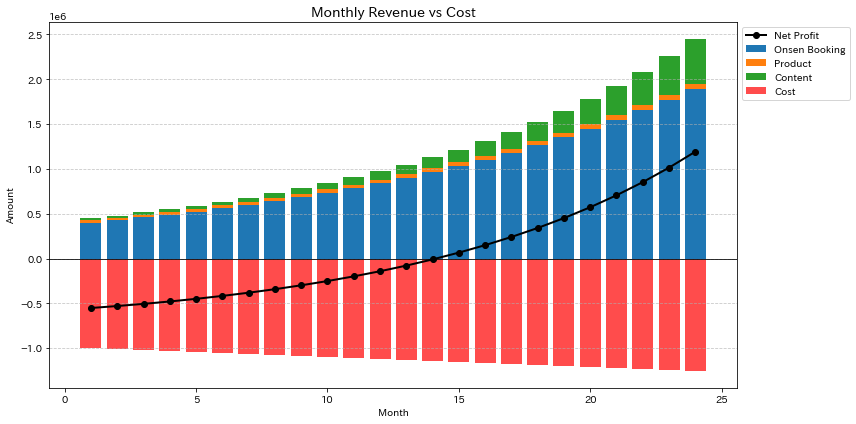

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# positive
plt.bar(df['Month'], df['Revenue'], label='Onsen Booking', color='#1f77b4')
plt.bar(df['Month'], df['Product'], bottom=df['Revenue'], label='Product', color='#ff7f0e')
plt.bar(df['Month'], df['Content'], bottom=df['Revenue'] + df['Product'], label='Content', color='#2ca02c')

# negative 
plt.bar(df['Month'], df['Cost'], label='Cost', color='red', alpha=0.7)


net_profit = df['Total_rev'] + df['Cost']
plt.plot(df['Month'], net_profit, marker='o', color='black', label='Net Profit', linewidth=2) # line graph 

plt.axhline(0, color='black', linewidth=0.8) 
plt.title('Monthly Revenue vs Cost', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# ユーザー数を反映させたグラフにもしたい：